# Retrieval Results Visualization

Notebook for visualizing outputs from the parallel retrieval workflow (`parallel_cli` / `scripts/slurm/run_retrieval_parallel.sh`).

Default configuration in this notebook:
- `OUTPUT_PREFIX = "my_run_fast"`
- `RESULTS_SUBDIR = "full"`
            


In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "This notebook requires seaborn. Install with: uv add seaborn or pip install seaborn"
    ) from exc

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "#F8FAFC",
        "axes.edgecolor": "#D1D5DB",
        "grid.color": "#E5E7EB",
        "axes.titleweight": "bold",
    },
)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
            


In [2]:
# --- Run configuration ---
OUTPUT_PREFIX = "my_run_fast"
RESULTS_SUBDIR = "full"  # "full" or "subsample"

# Performance tuning for large detail tables.
DETAIL_SAMPLE_PER_GROUP = 4000
RANDOM_STATE = 7

candidate_roots = [Path("."), Path("..")]
results_dir = None
for root in candidate_roots:
    candidate = (root / "results" / RESULTS_SUBDIR).resolve()
    if candidate.exists():
        results_dir = candidate
        break

if results_dir is None:
    raise FileNotFoundError(
        "Could not find results directory. Expected ./results/{subdir} or ../results/{subdir}."
    )


def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)


def read_csv_optional(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


paths = {
    "summary_overall": results_dir / f"{OUTPUT_PREFIX}_summary_overall.csv",
    "summary_by_cell": results_dir / f"{OUTPUT_PREFIX}_summary_by_cell_type.csv",
    "detail": results_dir / f"{OUTPUT_PREFIX}_detail.csv",
    "tasks": results_dir / f"{OUTPUT_PREFIX}_tasks.csv",
    "truth_summary": results_dir / f"{OUTPUT_PREFIX}_truth_summary.csv",
    "truth_matches": results_dir / f"{OUTPUT_PREFIX}_truth_matches.csv",
}

summary_overall_df = read_csv_required(paths["summary_overall"])
summary_by_cell_df = read_csv_required(paths["summary_by_cell"])
detail_df = read_csv_required(paths["detail"])
tasks_df = read_csv_optional(paths["tasks"])
truth_summary_df = read_csv_optional(paths["truth_summary"])
truth_matches_df = read_csv_optional(paths["truth_matches"])

print(f"Using results directory: {results_dir}")
for key, p in paths.items():
    exists = p.exists()
    size = f"{p.stat().st_size / 1e6:.1f} MB" if exists else "missing"
    print(f"- {key:14s} | exists={str(exists):5s} | {p.name} | {size}")
            


Using results directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/full
- summary_overall | exists=True  | my_run_fast_summary_overall.csv | 0.0 MB
- summary_by_cell | exists=True  | my_run_fast_summary_by_cell_type.csv | 0.2 MB
- detail         | exists=True  | my_run_fast_detail.csv | 178.9 MB
- tasks          | exists=True  | my_run_fast_tasks.csv | 0.1 MB
- truth_summary  | exists=True  | my_run_fast_truth_summary.csv | 0.0 MB
- truth_matches  | exists=True  | my_run_fast_truth_matches.csv | 8.2 MB


In [3]:
for df in [summary_overall_df, summary_by_cell_df, detail_df, tasks_df, truth_summary_df]:
    if not df.empty and {"query_dataset", "db_dataset"}.issubset(df.columns):
        df["pair"] = df["query_dataset"].astype(str) + " -> " + df["db_dataset"].astype(str)

pair_order = sorted(summary_overall_df["pair"].dropna().unique().tolist())
metric_order = sorted(summary_overall_df["metric"].dropna().unique().tolist())
representation_order = (
    summary_overall_df.groupby("representation", as_index=False)["retrieval_score_mean"]
    .mean()
    .sort_values("retrieval_score_mean", ascending=False)["representation"]
    .tolist()
)

overview = pd.DataFrame(
    [
        {"table": "summary_overall", "rows": len(summary_overall_df)},
        {"table": "summary_by_cell", "rows": len(summary_by_cell_df)},
        {"table": "detail", "rows": len(detail_df)},
        {"table": "tasks", "rows": len(tasks_df)},
        {"table": "truth_summary", "rows": len(truth_summary_df)},
        {"table": "truth_matches", "rows": len(truth_matches_df)},
    ]
)
display(overview)

display(
    summary_overall_df.sort_values("retrieval_score_mean", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
            


,table,rows
0,summary_overall,216
1,summary_by_cell,1080
2,detail,1023798
3,tasks,360
4,truth_summary,60
5,truth_matches,60978


,query_dataset,db_dataset,representation,metric,n_queries,n_candidates_mean,n_candidates_median,rank_mean,rank_median,rank_over_n_mean,rank_normalized_mean,retrieval_score_mean,retrieval_score_median,pair
0,l1000_phase1,l1000_phase2,signed_-log10(p)*sign(logFC),pearson,16358,7916.085463,11134.0,2465.728757,715.5,0.280799,0.280592,0.719408,0.857755,l1000_phase1 -> l1000_phase2
1,l1000_phase1,l1000_phase2,signed_-log10(p)*sign(logFC),cosine,16358,7916.085463,11134.0,2475.547011,726.5,0.282158,0.281952,0.718048,0.856049,l1000_phase1 -> l1000_phase2
2,l1000_phase1,l1000_phase2,t,pearson,16358,7916.085463,11134.0,2487.462587,763.5,0.287146,0.286943,0.713057,0.840397,l1000_phase1 -> l1000_phase2
3,l1000_phase1,l1000_phase2,t,cosine,16358,7916.085463,11134.0,2499.412826,767.0,0.288777,0.288574,0.711426,0.837970,l1000_phase1 -> l1000_phase2
4,sciplex,l1000_phase2,t,cosine,561,7761.294118,11755.0,2345.424242,765.0,0.291460,0.291279,0.708721,0.830696,sciplex -> l1000_phase2
5,sciplex,l1000_phase2,t,pearson,561,7761.294118,11755.0,2352.688057,774.0,0.292334,0.292153,0.707847,0.835460,sciplex -> l1000_phase2
6,sciplex,l1000_phase2,signed_-log10(p)*sign(logFC),pearson,561,7761.294118,11755.0,2435.274510,776.0,0.303636,0.303458,0.696542,0.804917,sciplex -> l1000_phase2
7,sciplex,l1000_phase2,signed_-log10(p)*sign(logFC),cosine,561,7761.294118,11755.0,2429.652406,774.0,0.303710,0.303532,0.696468,0.800487,sciplex -> l1000_phase2
8,l1000_phase1,l1000_phase2,B,pearson,16358,7916.085463,11134.0,2595.529099,907.0,0.304168,0.303971,0.696029,0.811585,l1000_phase1 -> l1000_phase2
9,tahoe,sciplex,P.Value,mrrmse,72,914.000000,914.0,278.569444,252.5,0.304781,0.304019,0.695981,0.724535,tahoe -> sciplex


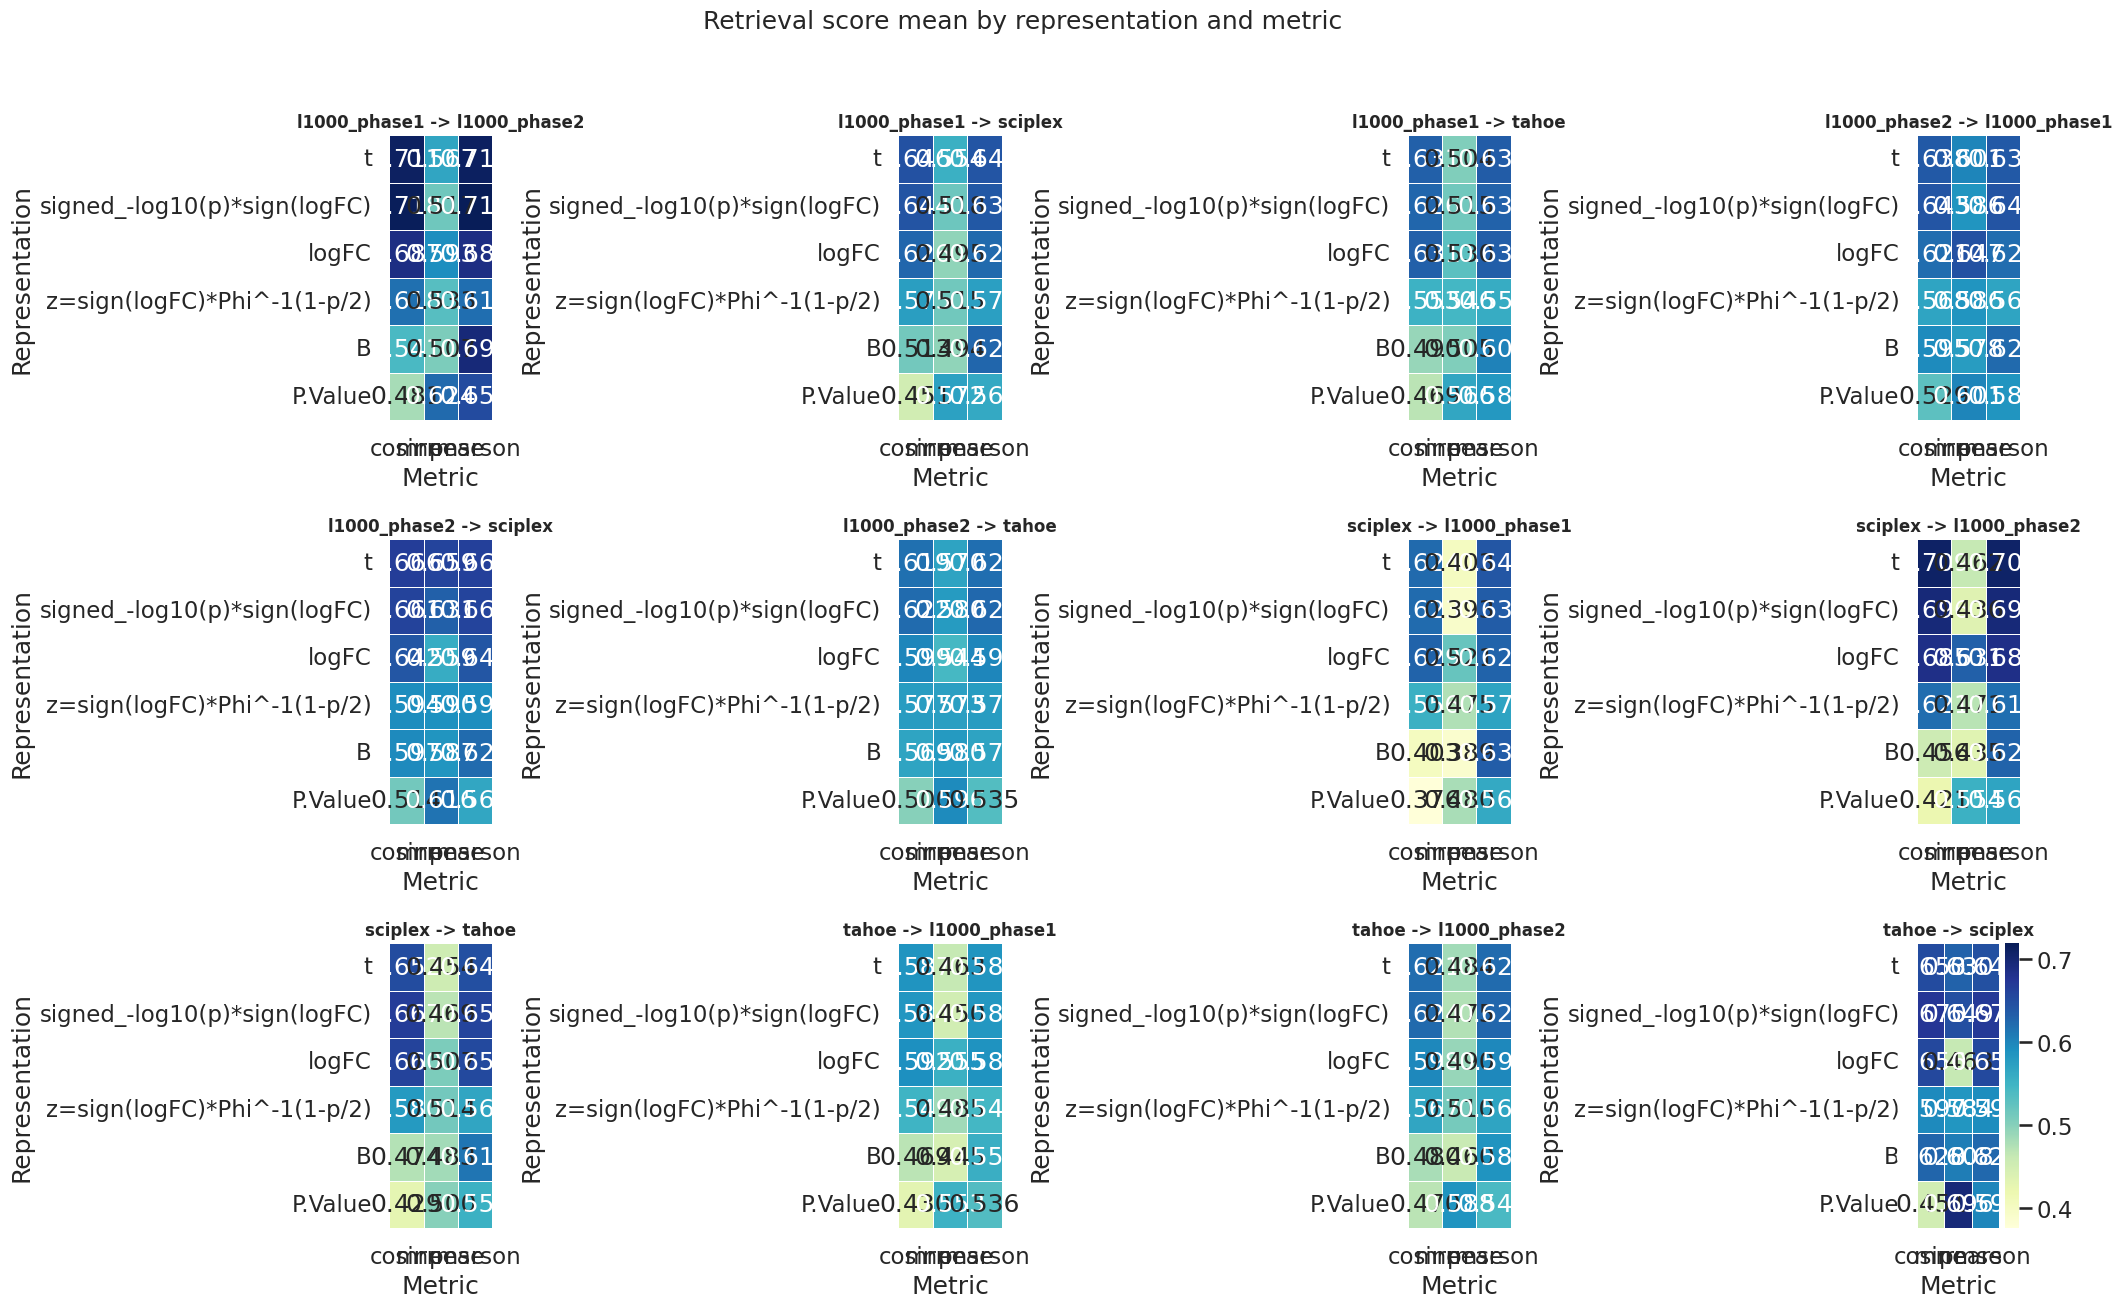

In [4]:
# Overall score heatmaps: one panel per query->db pair.
n_pairs = len(pair_order)
if n_pairs == 0:
    raise ValueError("No dataset pairs found in summary_overall_df.")

ncols = min(4, n_pairs)
nrows = math.ceil(n_pairs / ncols)

vmin = float(summary_overall_df["retrieval_score_mean"].min())
vmax = float(summary_overall_df["retrieval_score_mean"].max())

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 4.3 * nrows))
axes = np.atleast_1d(axes).ravel()

for idx, pair in enumerate(pair_order):
    ax = axes[idx]
    sub = summary_overall_df.loc[summary_overall_df["pair"] == pair]
    pivot = sub.pivot(index="representation", columns="metric", values="retrieval_score_mean")
    pivot = pivot.reindex(index=representation_order, columns=metric_order)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
        cbar=(idx == n_pairs - 1),
    )
    ax.set_title(pair, fontsize=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Representation")

for ax in axes[n_pairs:]:
    ax.axis("off")

fig.suptitle("Retrieval score mean by representation and metric", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()
            


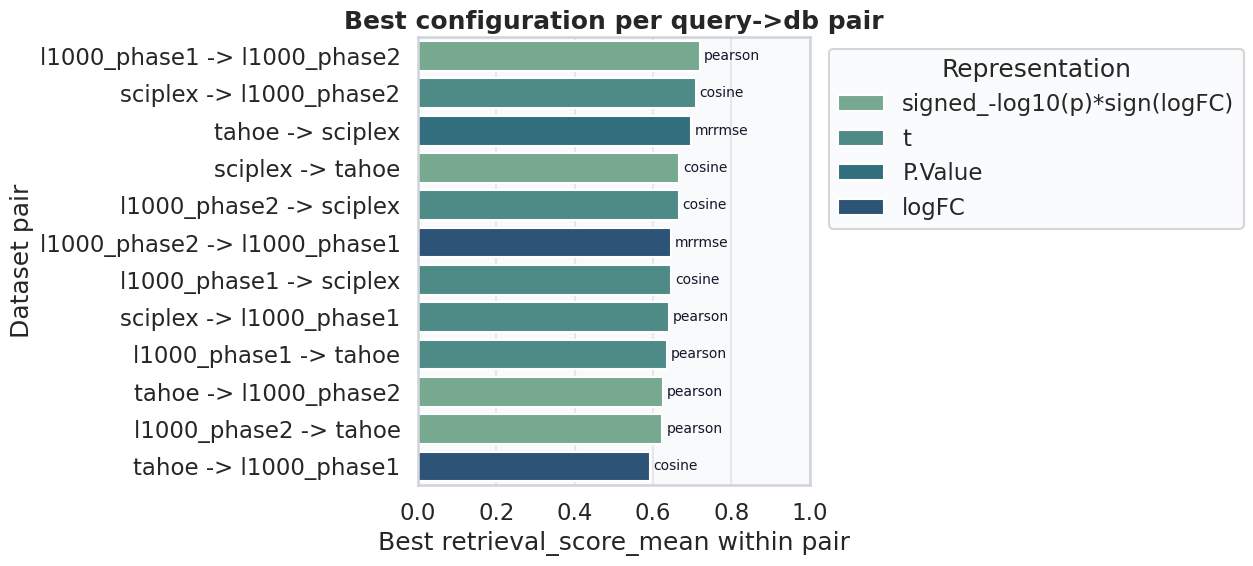

,pair,representation,metric,retrieval_score_mean,retrieval_score_median,n_queries
0,l1000_phase1 -> l1000_phase2,signed_-log10(p)*sign(logFC),pearson,0.719408,0.857755,16358
1,sciplex -> l1000_phase2,t,cosine,0.708721,0.830696,561
2,tahoe -> sciplex,P.Value,mrrmse,0.695981,0.724535,72
3,sciplex -> tahoe,signed_-log10(p)*sign(logFC),cosine,0.667395,0.737401,119
4,l1000_phase2 -> sciplex,t,cosine,0.666037,0.756428,1032
5,l1000_phase2 -> l1000_phase1,logFC,mrrmse,0.646564,0.717172,38132
6,l1000_phase1 -> sciplex,t,cosine,0.646014,0.717185,1005
7,sciplex -> l1000_phase1,t,pearson,0.641347,0.696751,781
8,l1000_phase1 -> tahoe,t,pearson,0.636114,0.702918,633
9,tahoe -> l1000_phase2,signed_-log10(p)*sign(logFC),pearson,0.625735,0.682725,438


In [5]:
# Best representation+metric per pair.
best_per_pair = (
    summary_overall_df.sort_values("retrieval_score_mean", ascending=False)
    .groupby(["query_dataset", "db_dataset"], as_index=False)
    .first()
)
best_per_pair["pair"] = best_per_pair["query_dataset"] + " -> " + best_per_pair["db_dataset"]
best_per_pair["config"] = best_per_pair["representation"] + " | " + best_per_pair["metric"]
best_per_pair = best_per_pair.sort_values("retrieval_score_mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(13, max(6, 0.42 * len(best_per_pair))))
ax = sns.barplot(
    data=best_per_pair,
    y="pair",
    x="retrieval_score_mean",
    hue="representation",
    dodge=False,
    palette="crest",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Best retrieval_score_mean within pair")
ax.set_ylabel("Dataset pair")
ax.set_title("Best configuration per query->db pair")
ax.legend(title="Representation", bbox_to_anchor=(1.02, 1), loc="upper left")

for i, (_, row) in enumerate(best_per_pair.iterrows()):
    ax.text(
        min(row["retrieval_score_mean"] + 0.01, 0.99),
        i,
        f"{row['metric']}",
        va="center",
        fontsize=10,
        color="#111827",
    )

plt.tight_layout()
plt.show()

display(
    best_per_pair[
        ["pair", "representation", "metric", "retrieval_score_mean", "retrieval_score_median", "n_queries"]
    ].head(20)
)
            


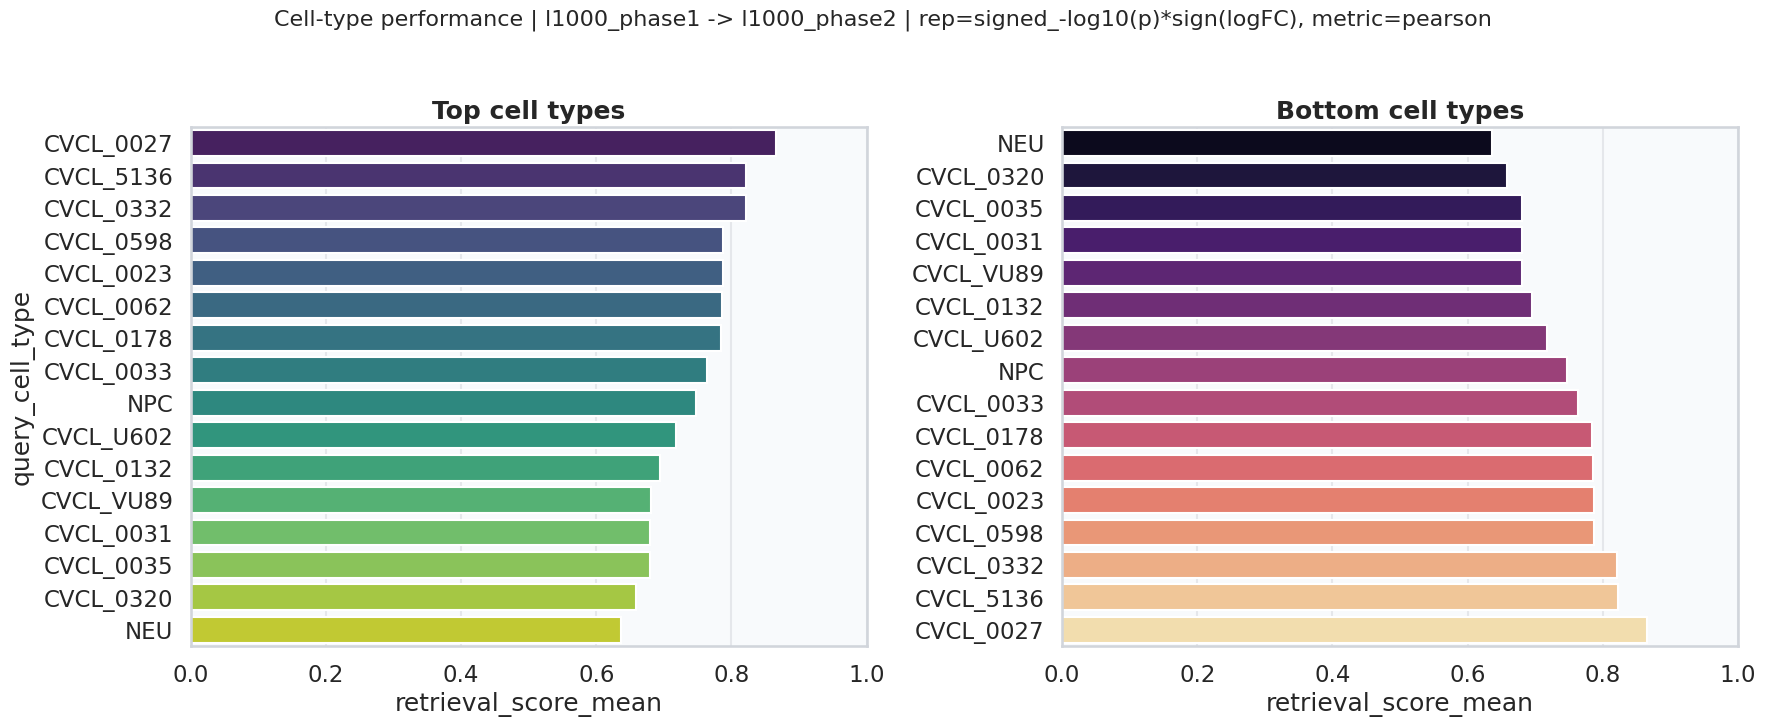

,query_dataset,db_dataset,query_cell_type,representation,metric,n_queries,n_candidates_mean,n_candidates_median,rank_mean,rank_median,rank_over_n_mean,rank_normalized_mean,retrieval_score_mean,retrieval_score_median,pair
0,l1000_phase1,l1000_phase2,CVCL_0027,signed_-log10(p)*sign(logFC),pearson,232,2310.0,2310.0,311.711207,64.5,0.134940,0.134565,0.865435,0.972499,l1000_phase1 -> l1000_phase2
1,l1000_phase1,l1000_phase2,CVCL_5136,signed_-log10(p)*sign(logFC),pearson,281,2306.0,2306.0,410.693950,109.0,0.178098,0.177741,0.822259,0.953145,l1000_phase1 -> l1000_phase2
2,l1000_phase1,l1000_phase2,CVCL_0332,signed_-log10(p)*sign(logFC),pearson,929,1614.0,1614.0,289.247578,71.0,0.179212,0.178703,0.821297,0.956603,l1000_phase1 -> l1000_phase2
3,l1000_phase1,l1000_phase2,CVCL_0598,signed_-log10(p)*sign(logFC),pearson,885,1638.0,1638.0,349.144633,111.0,0.213153,0.212672,0.787328,0.932804,l1000_phase1 -> l1000_phase2
4,l1000_phase1,l1000_phase2,CVCL_0023,signed_-log10(p)*sign(logFC),pearson,693,2056.0,2056.0,438.577201,115.0,0.213316,0.212933,0.787067,0.944526,l1000_phase1 -> l1000_phase2
5,l1000_phase1,l1000_phase2,CVCL_0062,signed_-log10(p)*sign(logFC),pearson,773,1638.0,1638.0,351.454075,111.0,0.214563,0.214083,0.785917,0.932804,l1000_phase1 -> l1000_phase2
6,l1000_phase1,l1000_phase2,CVCL_0178,signed_-log10(p)*sign(logFC),pearson,798,1488.0,1488.0,322.368421,106.0,0.216645,0.216119,0.783881,0.929388,l1000_phase1 -> l1000_phase2
7,l1000_phase1,l1000_phase2,CVCL_0033,signed_-log10(p)*sign(logFC),pearson,1107,1626.0,1626.0,384.732611,143.0,0.236613,0.236143,0.763857,0.912615,l1000_phase1 -> l1000_phase2
8,l1000_phase1,l1000_phase2,NPC,signed_-log10(p)*sign(logFC),pearson,89,1605.0,1605.0,406.067416,142.0,0.253002,0.252536,0.747464,0.912095,l1000_phase1 -> l1000_phase2
9,l1000_phase1,l1000_phase2,CVCL_U602,signed_-log10(p)*sign(logFC),pearson,57,1580.0,1580.0,446.280702,243.0,0.282456,0.282002,0.717998,0.846738,l1000_phase1 -> l1000_phase2


In [6]:
# Cell-type deep dive for one selected setup.
SELECT_QUERY_DATASET = None
SELECT_DB_DATASET = None
SELECT_REPRESENTATION = None
SELECT_METRIC = None
TOP_N = 20

if any(v is None for v in [SELECT_QUERY_DATASET, SELECT_DB_DATASET, SELECT_REPRESENTATION, SELECT_METRIC]):
    best_row = summary_overall_df.sort_values("retrieval_score_mean", ascending=False).iloc[0]
    SELECT_QUERY_DATASET = best_row["query_dataset"]
    SELECT_DB_DATASET = best_row["db_dataset"]
    SELECT_REPRESENTATION = best_row["representation"]
    SELECT_METRIC = best_row["metric"]

cell_sub = summary_by_cell_df[
    (summary_by_cell_df["query_dataset"] == SELECT_QUERY_DATASET)
    & (summary_by_cell_df["db_dataset"] == SELECT_DB_DATASET)
    & (summary_by_cell_df["representation"] == SELECT_REPRESENTATION)
    & (summary_by_cell_df["metric"] == SELECT_METRIC)
].copy()

cell_sub = cell_sub.sort_values("retrieval_score_mean", ascending=False).reset_index(drop=True)
top = cell_sub.head(TOP_N).copy()
bottom = cell_sub.tail(TOP_N).sort_values("retrieval_score_mean", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.36 * TOP_N)), sharex=True)

sns.barplot(
    data=top,
    x="retrieval_score_mean",
    y="query_cell_type",
    hue="query_cell_type",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top cell types")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("retrieval_score_mean")
axes[0].set_ylabel("query_cell_type")

sns.barplot(
    data=bottom,
    x="retrieval_score_mean",
    y="query_cell_type",
    hue="query_cell_type",
    dodge=False,
    legend=False,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Bottom cell types")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("retrieval_score_mean")
axes[1].set_ylabel("")

fig.suptitle(
    f"Cell-type performance | {SELECT_QUERY_DATASET} -> {SELECT_DB_DATASET} | "
    f"rep={SELECT_REPRESENTATION}, metric={SELECT_METRIC}",
    y=1.02,
    fontsize=16,
)
plt.tight_layout()
plt.show()

display(cell_sub.head(25))
            


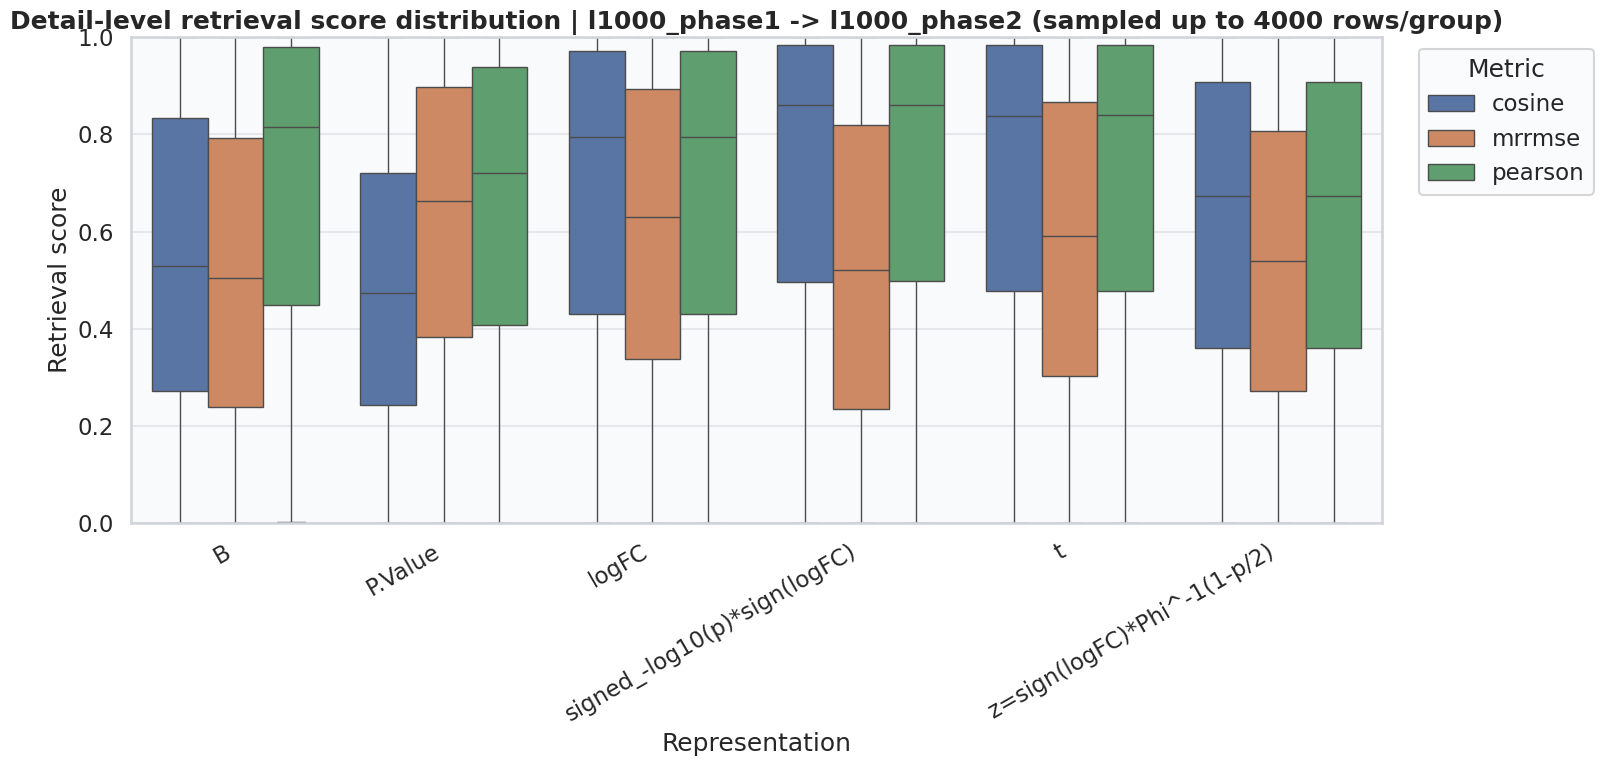

,representation,metric,n_queries,retrieval_score_mean,retrieval_score_median,rank_mean,n_candidates_mean
0,signed_-log10(p)*sign(logFC),pearson,16358,0.719408,0.857755,2465.728757,7916.085463
1,signed_-log10(p)*sign(logFC),cosine,16358,0.718048,0.856049,2475.547011,7916.085463
2,t,pearson,16358,0.713057,0.840397,2487.462587,7916.085463
3,t,cosine,16358,0.711426,0.837970,2499.412826,7916.085463
4,B,pearson,16358,0.696029,0.811585,2595.529099,7916.085463
5,logFC,pearson,16358,0.687497,0.793389,2679.716897,7916.085463
6,logFC,cosine,16358,0.687497,0.793389,2679.720993,7916.085463
7,P.Value,pearson,16358,0.652719,0.723528,2832.304560,7916.085463
8,P.Value,mrrmse,16358,0.623907,0.672638,3159.424930,7916.085463
9,z=sign(logFC)*Phi^-1(1-p/2),pearson,8902,0.619407,0.677204,2590.150640,6394.161312


In [7]:
def sample_per_group(df: pd.DataFrame, group_cols: list[str], n_per_group: int, random_state: int = 0) -> pd.DataFrame:
    if n_per_group <= 0:
        return df
    frames = []
    for _, g in df.groupby(group_cols, dropna=False, sort=False):
        if len(g) > n_per_group:
            frames.append(g.sample(n=n_per_group, random_state=random_state))
        else:
            frames.append(g)
    return pd.concat(frames, ignore_index=True) if frames else df


PAIR_FOR_DETAIL = (SELECT_QUERY_DATASET, SELECT_DB_DATASET)
MAX_REPRESENTATIONS = 6

detail_sub = detail_df[
    (detail_df["query_dataset"] == PAIR_FOR_DETAIL[0])
    & (detail_df["db_dataset"] == PAIR_FOR_DETAIL[1])
].copy()

top_reps = (
    detail_sub.groupby("representation", as_index=False)["retrieval_score"]
    .mean()
    .sort_values("retrieval_score", ascending=False)["representation"]
    .head(MAX_REPRESENTATIONS)
    .tolist()
)
detail_sub = detail_sub[detail_sub["representation"].isin(top_reps)].copy()

sampled = sample_per_group(
    detail_sub,
    group_cols=["representation", "metric"],
    n_per_group=DETAIL_SAMPLE_PER_GROUP,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=sampled,
    x="representation",
    y="retrieval_score",
    hue="metric",
    showfliers=False,
    linewidth=1.0,
)
plt.ylim(0, 1)
plt.xlabel("Representation")
plt.ylabel("Retrieval score")
plt.xticks(rotation=30, ha="right")
plt.title(
    f"Detail-level retrieval score distribution | {PAIR_FOR_DETAIL[0]} -> {PAIR_FOR_DETAIL[1]} "
    f"(sampled up to {DETAIL_SAMPLE_PER_GROUP} rows/group)"
)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

detail_stats = (
    detail_sub.groupby(["representation", "metric"], as_index=False)
    .agg(
        n_queries=("retrieval_score", "size"),
        retrieval_score_mean=("retrieval_score", "mean"),
        retrieval_score_median=("retrieval_score", "median"),
        rank_mean=("rank", "mean"),
        n_candidates_mean=("n_candidates", "mean"),
    )
    .sort_values("retrieval_score_mean", ascending=False)
    .reset_index(drop=True)
)
display(detail_stats.head(30))
            


Task detail files found: 360/360 (100.0%)


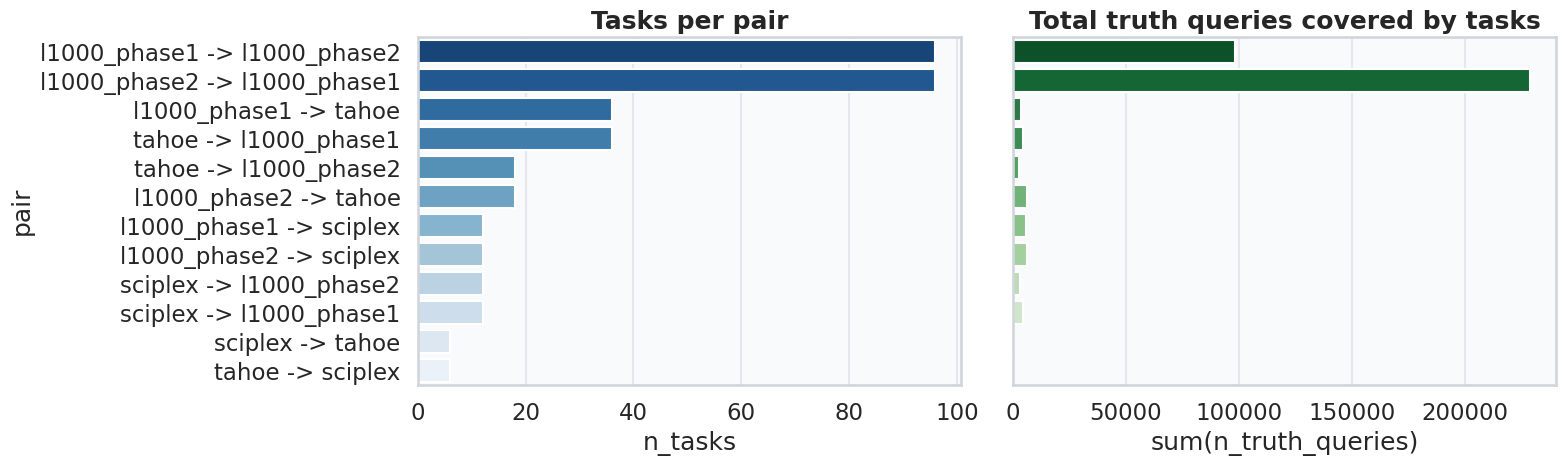

,pair,n_tasks,n_truth_queries
0,l1000_phase1 -> l1000_phase2,96,98148
3,l1000_phase2 -> l1000_phase1,96,228792
2,l1000_phase1 -> tahoe,36,3798
9,tahoe -> l1000_phase1,36,4644
10,tahoe -> l1000_phase2,18,2628
5,l1000_phase2 -> tahoe,18,6438
1,l1000_phase1 -> sciplex,12,6030
4,l1000_phase2 -> sciplex,12,6192
7,sciplex -> l1000_phase2,12,3366
6,sciplex -> l1000_phase1,12,4686


,pair,n_cell_types,n_truth_queries,mean_shared_cids
3,l1000_phase2 -> l1000_phase1,16,38132,316.000000
0,l1000_phase1 -> l1000_phase2,16,16358,316.000000
5,l1000_phase2 -> tahoe,3,1073,47.666667
4,l1000_phase2 -> sciplex,2,1032,64.000000
1,l1000_phase1 -> sciplex,2,1005,88.500000
6,sciplex -> l1000_phase1,2,781,88.500000
9,tahoe -> l1000_phase1,6,774,42.833333
2,l1000_phase1 -> tahoe,6,633,42.833333
7,sciplex -> l1000_phase2,2,561,64.000000
10,tahoe -> l1000_phase2,3,438,47.666667


In [8]:
if tasks_df.empty and truth_summary_df.empty:
    print("No tasks/truth files found for this run. Skipping diagnostics.")
else:
    if not tasks_df.empty:
        task_dir = results_dir / "tasks"
        tasks_diag = tasks_df.copy()
        tasks_diag["detail_file_exists"] = tasks_diag["task_detail_file"].apply(
            lambda x: (task_dir / str(x)).exists() if pd.notna(x) and str(x).strip() else False
        )
        completion = tasks_diag["detail_file_exists"].mean()
        print(
            f"Task detail files found: {tasks_diag['detail_file_exists'].sum():,}/{len(tasks_diag):,} "
            f"({completion:.1%})"
        )

        tasks_per_pair = (
            tasks_diag.groupby("pair", as_index=False)
            .agg(
                n_tasks=("task_id", "count"),
                n_truth_queries=("n_truth_queries", "sum"),
            )
            .sort_values("n_tasks", ascending=False)
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.32 * len(tasks_per_pair))), sharey=True)
        sns.barplot(
            data=tasks_per_pair,
            y="pair",
            x="n_tasks",
            hue="pair",
            dodge=False,
            legend=False,
            ax=axes[0],
            palette="Blues_r",
        )
        axes[0].set_title("Tasks per pair")
        axes[0].set_xlabel("n_tasks")
        axes[0].set_ylabel("pair")

        sns.barplot(
            data=tasks_per_pair,
            y="pair",
            x="n_truth_queries",
            hue="pair",
            dodge=False,
            legend=False,
            ax=axes[1],
            palette="Greens_r",
        )
        axes[1].set_title("Total truth queries covered by tasks")
        axes[1].set_xlabel("sum(n_truth_queries)")
        axes[1].set_ylabel("")

        plt.tight_layout()
        plt.show()

        display(tasks_per_pair.head(20))

    if not truth_summary_df.empty:
        truth_by_pair = (
            truth_summary_df.groupby("pair", as_index=False)
            .agg(
                n_cell_types=("query_cell_type", "nunique"),
                n_truth_queries=("n_truth_queries", "sum"),
                mean_shared_cids=("n_shared_pubchem_cids", "mean"),
            )
            .sort_values("n_truth_queries", ascending=False)
        )
        display(truth_by_pair)
            
